# Base ASHRAE Global Thermal Comfort Database II
## Vérification et filtrage

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
# Fichiers pour les résultats
import os

# Dossier principal
OUT = "resultats"

# Sous-dossiers
GRAPH = os.path.join(OUT, "graphiques")
CSV = os.path.join(OUT, "csv")

# Création des dossiers
os.makedirs(GRAPH, exist_ok=True)
os.makedirs(CSV, exist_ok=True)

In [3]:
import os

chemin = r"C:\Users\Icebear\Documents\PFE\Cassy\files\A_lire"
print(os.path.exists(chemin))

True


In [4]:
import os

print(os.listdir(r"C:\Users\Icebear\Documents\PFE\Cassy\files\A_lire"))

['db_measurements_v2.1.0.csv', 'db_metadata.csv', 'parameter_description.pdf']


### Vérification des études

In [5]:
import os

print(os.path.exists(r"C:\Users\Icebear\Documents\PFE\Cassy\files\A_lire\db_metadata.csv"))
print(os.path.exists(r"C:\Users\Icebear\Documents\PFE\Cassy\files\A_lire\db_measurements_v2.1.0.csv"))

True
True


In [6]:
meta = pd.read_csv(
    r"C:\Users\Icebear\Documents\PFE\Cassy\files\A_lire\db_metadata.csv",
    encoding="utf-8"
)

mes = pd.read_csv(
    r"C:\Users\Icebear\Documents\PFE\Cassy\files\A_lire\db_measurements_v2.1.0.csv",
    low_memory=False,
    encoding="utf-8"
)

In [7]:
print("=" * 70)
print("ETAPE 0 : vérification des 6 études")
print("=" * 70)

ETAPE 0 : vérification des 6 études


In [8]:
# Etude 1 : Indraganti

indraganti = meta[
    meta["publication"].str.contains(
        "10.1016/j.buildenv.2014.01.002",
        case=False,
        na=False
    )
]

print("Indraganti")

print("Pays:", indraganti["country"].unique())
print("Ville :", indraganti["city"].unique())
print("Climat :", indraganti["climate"].unique())
print("Type_bâtiment:", indraganti["building_type"].unique())
print("Mode de climatisation :", indraganti["cooling_type"].unique())
print("Nombre de bâtiments :", len(indraganti))
print("Nombre de votes :", indraganti["records"].sum())

Indraganti
Pays: ['india']
Ville : ['chennai' 'hyderabad']
Climat : ['tropical wet savanna' 'hot semi-arid']
Type_bâtiment: ['office']
Mode de climatisation : ['air conditioned' 'mixed mode' 'naturally ventilated']
Nombre de bâtiments : 10
Nombre de votes : 6048


In [9]:
print("Nombre de building_id :", indraganti["building_id"].nunique())
print("Liste des building_id :")
print(sorted(indraganti["building_id"].unique()))

Nombre de building_id : 10
Liste des building_id :
[np.int64(653), np.int64(654), np.int64(655), np.int64(656), np.int64(657), np.int64(658), np.int64(659), np.int64(660), np.int64(661), np.int64(662)]


In [10]:
batiments = (
    indraganti
    .groupby("building_id")["records"]
    .first()
    .reset_index()
)

batiments

,building_id,records
0,653,101
1,654,1527
2,655,152
3,656,1127
4,657,70
5,658,1830
6,659,58
7,660,63
8,661,1085
9,662,35


In [11]:
batiments["records"].sum()

np.int64(6048)

In [12]:
pd.crosstab(
    indraganti["city"],
    indraganti["climate"]
)

climate,hot semi-arid,tropical wet savanna
city,,
chennai,0,4
hyderabad,6,0


In [13]:
pd.crosstab(
    indraganti["cooling_type"],
    indraganti["city"]
)

city,chennai,hyderabad
cooling_type,,
air conditioned,2,2
mixed mode,2,2
naturally ventilated,0,2


In [14]:
indraganti.groupby("cooling_type")["building_id"].nunique()

cooling_type
air conditioned         4
mixed mode              4
naturally ventilated    2
Name: building_id, dtype: int64

In [15]:
print(indraganti.columns.tolist())

['building_id', 'building_id_inf', 'contributor', 'publication', 'region', 'country', 'city', 'lat', 'lon', 'climate', 'building_type', 'cooling_type', 'year', 'records', 'has_age', 'has_ec', 'has_timestamp', 'timezone', 'met_source', 'isd_station', 'isd_distance', 'database', 'quality_assurance']


In [16]:
indraganti.groupby("building_id")["city"].first()
indraganti.groupby("building_id")["cooling_type"].first()
indraganti.groupby("building_id")["records"].first()

building_id
653     101
654    1527
655     152
656    1127
657      70
658    1830
659      58
660      63
661    1085
662      35
Name: records, dtype: int64

In [17]:
indraganti[
    ["building_id","city","cooling_type"]
].drop_duplicates().sort_values("building_id")

,building_id,city,cooling_type
652,653,chennai,air conditioned
653,654,chennai,mixed mode
654,655,chennai,air conditioned
655,656,chennai,mixed mode
656,657,hyderabad,air conditioned
657,658,hyderabad,mixed mode
658,659,hyderabad,naturally ventilated
659,660,hyderabad,air conditioned
660,661,hyderabad,mixed mode
661,662,hyderabad,naturally ventilated


In [18]:
indraganti.groupby("building_id")["publication"].unique()

building_id
653    [https://doi.org/10.1016/j.buildenv.2014.01.002]
654    [https://doi.org/10.1016/j.buildenv.2014.01.002]
655    [https://doi.org/10.1016/j.buildenv.2014.01.002]
656    [https://doi.org/10.1016/j.buildenv.2014.01.002]
657    [https://doi.org/10.1016/j.buildenv.2014.01.002]
658    [https://doi.org/10.1016/j.buildenv.2014.01.002]
659    [https://doi.org/10.1016/j.buildenv.2014.01.002]
660    [https://doi.org/10.1016/j.buildenv.2014.01.002]
661    [https://doi.org/10.1016/j.buildenv.2014.01.002]
662    [https://doi.org/10.1016/j.buildenv.2014.01.002]
Name: publication, dtype: object

In [19]:
indraganti.groupby("building_id")["year"].unique()
indraganti.groupby("building_id")["city"].unique()

building_id
653      [chennai]
654      [chennai]
655      [chennai]
656      [chennai]
657    [hyderabad]
658    [hyderabad]
659    [hyderabad]
660    [hyderabad]
661    [hyderabad]
662    [hyderabad]
Name: city, dtype: object

In [20]:
# Etude 2 : Cândido
cândido = meta[
    meta["publication"].str.contains(
        "10.1016/j.buildenv.2009.06.005",
        case=False,
        na=False
    )
]

print("Cândido")

print("Pays:", cândido["country"].unique())
print("Ville :", cândido["city"].unique())
print("Climat :", cândido["climate"].unique())
print("Type_bâtiment:", cândido["building_type"].unique())
print("Mode de climatisation :", cândido["cooling_type"].unique())
print("Nombre de bâtiments :", indraganti["building_id"].nunique())
print("Nombre de votes :", cândido["records"].sum())

Cândido
Pays: ['brazil']
Ville : ['maceio']
Climat : ['tropical monsoon']
Type_bâtiment: ['classroom']
Mode de climatisation : ['naturally ventilated']
Nombre de bâtiments : 10
Nombre de votes : 2075


In [21]:
cândido[["building_id", "records"]].drop_duplicates().sort_values("building_id")

,building_id,records
590,591,915
591,592,1160


In [22]:
cândido[["building_id","city"]].drop_duplicates().sort_values("building_id")

,building_id,city
590,591,maceio
591,592,maceio


In [23]:
cândido["records"].sum()

np.int64(2075)

In [24]:
cândido.groupby("building_id")["records"].first()

building_id
591     915
592    1160
Name: records, dtype: int64

In [25]:
# Etude 3 : Alison G.KWOK
kwok = meta[
    meta["publication"].str.contains(
        "Kwok",
        case=False,
        na=False
    )
]

print("Kwok")

print("Pays:", kwok["country"].unique())
print("Ville :", kwok["city"].unique())
print("Climat :", kwok["climate"].unique())
print("Type_bâtiment:", kwok["building_type"].unique())
print("Mode de climatisation :", kwok["cooling_type"].unique())
print("Nombre de bâtiments :", kwok["building_id"].nunique())
print("Nombre de votes :", kwok["records"].sum())

Kwok
Pays: ['usa']
Ville : ['honolulu']
Climat : ['tropical savanna']
Type_bâtiment: ['office']
Mode de climatisation : ['naturally ventilated' 'air conditioned']
Nombre de bâtiments : 12
Nombre de votes : 3544


In [26]:
kwok[["building_id","records", "city", "building_type", "cooling_type"]].drop_duplicates().sort_values("building_id")

,building_id,records,city,building_type,cooling_type
153,154,34,honolulu,office,naturally ventilated
154,155,20,honolulu,office,naturally ventilated
155,156,540,honolulu,office,naturally ventilated
156,157,458,honolulu,office,naturally ventilated
157,158,95,honolulu,office,air conditioned
158,159,608,honolulu,office,air conditioned
159,160,43,honolulu,office,naturally ventilated
160,161,68,honolulu,office,naturally ventilated
161,162,495,honolulu,office,naturally ventilated
162,163,523,honolulu,office,naturally ventilated


In [27]:
kwok["records"].sum()

np.int64(3544)

In [28]:
kwok["publication"].unique()

array(['Kwok, A.G. (1998). Thermal Comfort in Tropical Classrooms. ASHRAE Transactions, 104.'],
      dtype=object)

In [29]:
kwok.groupby("cooling_type")["building_id"].nunique()

cooling_type
air conditioned         4
naturally ventilated    8
Name: building_id, dtype: int64

In [30]:
kwok.groupby("cooling_type")["records"].sum()

cooling_type
air conditioned         1363
naturally ventilated    2181
Name: records, dtype: int64

In [31]:
kwok[["building_id","cooling_type","records"]]

,building_id,cooling_type,records
153,154,naturally ventilated,34
154,155,naturally ventilated,20
155,156,naturally ventilated,540
156,157,naturally ventilated,458
157,158,air conditioned,95
158,159,air conditioned,608
159,160,naturally ventilated,43
160,161,naturally ventilated,68
161,162,naturally ventilated,495
162,163,naturally ventilated,523


In [32]:
kwok.columns.tolist()

['building_id',
 'building_id_inf',
 'contributor',
 'publication',
 'region',
 'country',
 'city',
 'lat',
 'lon',
 'climate',
 'building_type',
 'cooling_type',
 'year',
 'records',
 'has_age',
 'has_ec',
 'has_timestamp',
 'timezone',
 'met_source',
 'isd_station',
 'isd_distance',
 'database',
 'quality_assurance']

In [33]:
# Etude 4 : Manu
manu = meta[
    meta["publication"].str.contains(
        "10.1016/j.buildenv.2015.12.019",
        case=False,
        na=False
    )
]

print("Manu")

print("Pays:", manu["country"].unique())
print("Ville :", manu["city"].unique())
print("Climat :", manu["climate"].unique())
print("Type_bâtiment:", manu["building_type"].unique())
print("Mode de climatisation :", manu["cooling_type"].unique())
print("Nombre de bâtiments :", manu["building_id"].nunique())
print("Nombre de votes :", manu["records"].sum())

Manu
Pays: ['india']
Ville : ['ahmedabad' 'bangalore' 'chennai' 'delhi' 'shimla']
Climat : ['hot semi-arid' 'tropical wet savanna'
 'monsoon-influenced humid subtropical' 'subtropical highland']
Type_bâtiment: ['office']
Mode de climatisation : ['mixed mode' 'naturally ventilated' 'air conditioned']
Nombre de bâtiments : 20
Nombre de votes : 6330


In [34]:
manu[["building_id","city","cooling_type"]].drop_duplicates().sort_values("building_id")

,building_id,city,cooling_type
681,682,ahmedabad,mixed mode
682,683,ahmedabad,naturally ventilated
683,684,ahmedabad,mixed mode
684,685,ahmedabad,naturally ventilated
685,686,bangalore,air conditioned
686,687,bangalore,naturally ventilated
687,688,bangalore,air conditioned
688,689,bangalore,naturally ventilated
689,690,chennai,air conditioned
690,691,chennai,naturally ventilated


In [35]:
manu.groupby("cooling_type")["building_id"].nunique()

cooling_type
air conditioned         6
mixed mode              6
naturally ventilated    8
Name: building_id, dtype: int64

In [36]:
manu.groupby("city")["building_id"].nunique()

city
ahmedabad    4
bangalore    4
chennai      4
delhi        4
shimla       4
Name: building_id, dtype: int64

In [37]:
manu.groupby("building_id")["records"].first()

building_id
682    727
683    258
684    355
685    167
686    424
687    367
688    200
689    160
690    399
691    189
692    200
693     90
694    430
695    525
696    196
697    237
698    425
699    533
700    207
701    241
Name: records, dtype: int64

In [38]:
# Etude 5 : Damiati
damiati = meta[
    meta["publication"].str.contains(
        "10.1016/j.buildenv.2016.09.024",
        case=False,
        na=False
    )
]

print("Damiati")

print("Pays:", damiati["country"].unique())
print("Ville :", damiati["city"].unique())
print("Climat :", damiati["climate"].unique())
print("Type_bâtiment:", damiati["building_type"].unique())
print("Mode de climatisation :", damiati["cooling_type"].unique())
print("Nombre de bâtiments :", damiati["building_id"].nunique())
print("Nombre de votes :", damiati["records"].sum())

Damiati
Pays: ['indonesia' 'japan' 'malaysia' 'singapore']
Ville : ['bandung' 'setagaya' 'yokohama' 'kuala lumpur' 'shah alam' 'singapore']
Climat : ['tropical' 'temperate']
Type_bâtiment: ['office']
Mode de climatisation : ['air conditioned' 'mixed mode' 'naturally ventilated']
Nombre de bâtiments : 12
Nombre de votes : 2049


In [39]:
damiati[["building_id","city","cooling_type"]].drop_duplicates().sort_values("building_id")

,building_id,city,cooling_type
727,728,bandung,air conditioned
728,729,bandung,mixed mode
729,730,bandung,naturally ventilated
730,731,setagaya,air conditioned
731,732,setagaya,naturally ventilated
732,733,yokohama,air conditioned
733,734,yokohama,naturally ventilated
734,735,kuala lumpur,air conditioned
735,736,kuala lumpur,naturally ventilated
736,737,shah alam,air conditioned


In [40]:
# Etude 6 : Dear
dear = meta[
    meta["publication"].str.contains(
        "Fountain, M.E",
        case=False,
        na=False
    )
]

print("Dear")

print("Pays:", dear["country"].unique())
print("Ville :", dear["city"].unique())
print("Climat :", dear["climate"].unique())
print("Type_bâtiment:", dear["building_type"].unique())
print("Mode de climatisation :", dear["cooling_type"].unique())
print("Nombre de bâtiments :", dear["building_id"].nunique())
print("Nombre de votes :", dear["records"].sum())

Dear
Pays: ['australia']
Ville : ['townsville']
Climat : ['tropical savanna']
Type_bâtiment: ['office']
Mode de climatisation : ['air conditioned']
Nombre de bâtiments : 23
Nombre de votes : 1231


In [41]:
dear[["building_id","city","cooling_type"]].drop_duplicates().sort_values("building_id")

,building_id,city,cooling_type
87,88,townsville,air conditioned
88,89,townsville,air conditioned
89,90,townsville,air conditioned
90,91,townsville,air conditioned
91,92,townsville,air conditioned
92,93,townsville,air conditioned
93,94,townsville,air conditioned
94,95,townsville,air conditioned
95,96,townsville,air conditioned
96,97,townsville,air conditioned


In [42]:
print("=" * 70)
print("ETAPE 1 : définition clim_trop")
print("=" * 70)

ETAPE 1 : définition clim_trop


In [43]:
print(meta["climate"].value_counts())

climats_tropicaux = [
    "tropical wet savanna",   # Aw
    "tropical savanna",       # Aw (générique)
    "tropical rainforest",    # Af
    "wet equatorial",         # Af/Am
    "tropical monsoon",       # Am
    "tropical dry savanna",   # As
    "tropical",               # générique (ex: Damiati, Malaisie/Indo/Singapour)
]
meta["is_tropical"] = meta["climate"].isin(climats_tropicaux)

print(f"\nBâtiments tropicaux : {meta['is_tropical'].sum()} / {len(meta)}")
print(f"Votes tropicaux (metadata) : {meta.loc[meta['is_tropical'], 'records'].sum()}")

climate
tropical wet savanna                               162
hot semi-arid                                      101
humid subtropical                                   61
monsoon-influenced temperate oceanic                60
tropical savanna                                    55
hot-summer mediterranean                            41
monsoon-influenced humid subtropical                39
hot arid                                            38
temperate oceanic                                   37
mediterranean                                       31
temperate                                           30
continental subarctic                               23
west coast marine                                   20
hot desert                                          16
monsoon-influenced hot-summer humid continental     15
tropical rainforest                                 15
wet equatorial                                       9
tropical                                             8
wa

In [44]:
print("\nHORS climat tropical (top 10) :")
print(meta.loc[~meta["is_tropical"], "climate"].value_counts().head(10))
print("\nPays climat tropical :")
print(meta.loc[meta["is_tropical"], "country"].value_counts())


HORS climat tropical (top 10) :
climate
hot semi-arid                           101
humid subtropical                        61
monsoon-influenced temperate oceanic     60
hot-summer mediterranean                 41
monsoon-influenced humid subtropical     39
hot arid                                 38
temperate oceanic                        37
mediterranean                            31
temperate                                30
continental subarctic                    23
Name: count, dtype: int64

Pays climat tropical :
country
india          154
australia       38
malaysia        18
usa             12
indonesia       10
thailand         5
mexico           5
singapore        4
brazil           4
nigeria          2
philippines      1
Name: count, dtype: int64


In [45]:
print("=" * 70)
print("ETAPE 2 : fusion meta et measurements")
print("=" * 70)

ETAPE 2 : fusion meta et measurements


In [46]:
meta_utile = meta[["building_id", "publication", "city", "country", "climate",
                    "is_tropical", "building_type", "cooling_type"]]
df = mes.merge(meta_utile, on="building_id", how="left")

df_tropical = df[df["is_tropical"] == True].copy()
print(f"Total votes (toute la base)      : {len(df)}")
print(f"(B) Votes en climat TROPICAL      : {len(df_tropical)}  <- sous-ensemble B")

Total votes (toute la base)      : 109033
(B) Votes en climat TROPICAL      : 21974  <- sous-ensemble B


In [47]:
print("=" * 70)
print("ETAPE 3 : nuage de points")
print("=" * 70)

ETAPE 3 : nuage de points


In [48]:
resume = df_tropical.groupby("publication").agg(
    n_total=("vel", "size"),
    n_avec_vel=("vel", lambda s: s.notna().sum()),
).reset_index()
resume["pct_avec_vel"] = (resume["n_avec_vel"] / resume["n_total"] * 100).round(1)
resume = resume.sort_values("n_total", ascending=False)


noms_courts = {
    "10.1016/j.buildenv.2014.01.002": "Indraganti 2014",
    "10.1016/j.buildenv.2009.06.005": "Cândido 2010",
    "10.1016/j.buildenv.2015.12.019": "Manu 2016 IMAC",
    "10.1016/j.buildenv.2016.09.024": "Damiati 2016",
}
# Dictionnaire des études connues
noms_courts = {
    "10.1016/j.buildenv.2014.01.002": "Indraganti 2014",
    "10.1016/j.buildenv.2009.06.005": "Candido 2010",
    "10.1016/j.buildenv.2015.12.019": "Manu 2016",
    "10.1016/j.buildenv.2016.09.024": "Damiati 2016",
    "Kwok": "Kwok 1998 (Hawaii)",
    "Fountain": "de Dear 1994 (Townsville)"
}

def nom_court(pub):
    pub = str(pub)

    for mot, nom in noms_courts.items():
        if mot in pub:
            return nom

    # Rien : renvoie de la publication
    return pub

C:\Users\Icebear\AppData\Local\Temp\ipykernel_5892\3997226979.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


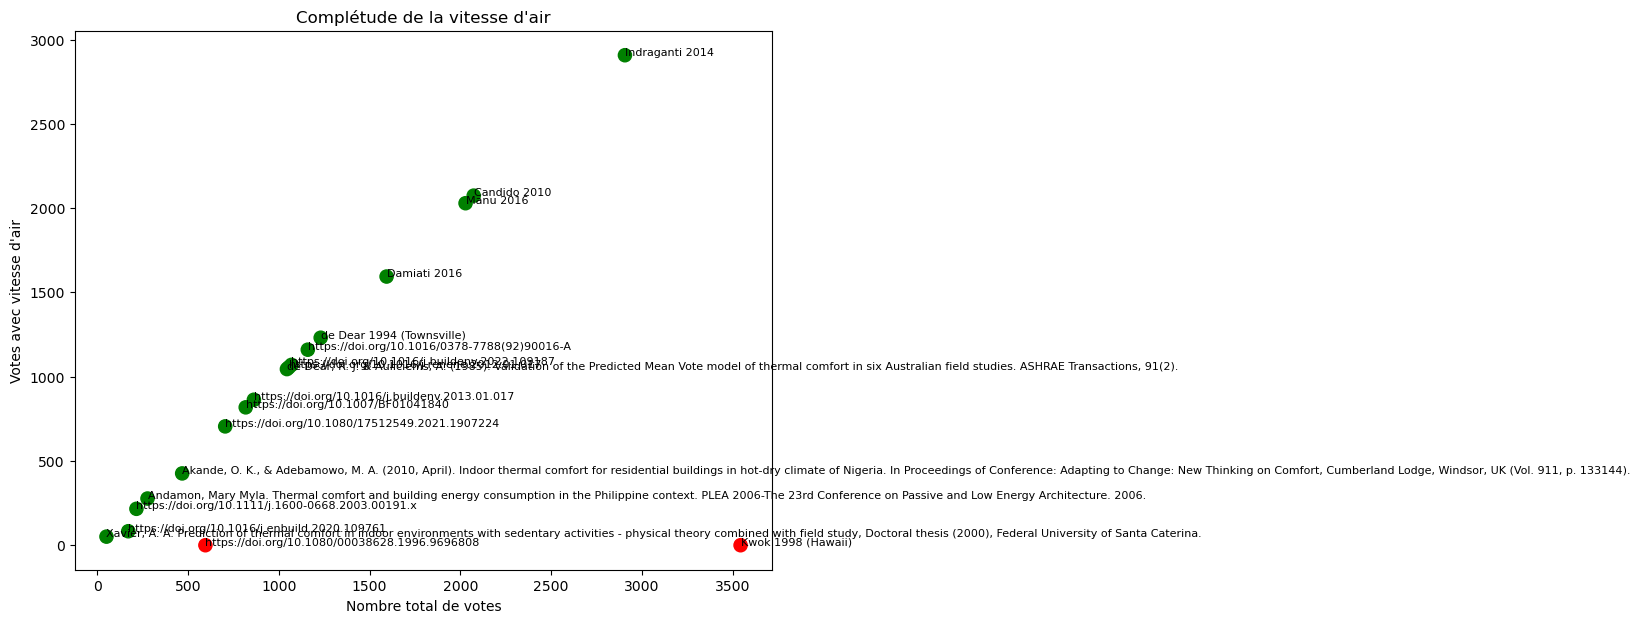

In [68]:
plt.figure(figsize=(9,7))

couleurs = []

for v in resume["n_avec_vel"]:
    if v == 0:
        couleurs.append("red")
    else:
        couleurs.append("green")

plt.scatter(
    resume["n_total"],
    resume["n_avec_vel"],
    color=couleurs,
    s=90
)

resume["nom"] = resume["publication"].apply(nom_court)

for i in range(len(resume)):
    plt.text(
        resume["n_total"].iloc[i],
        resume["n_avec_vel"].iloc[i],
        resume["nom"].iloc[i],
        fontsize=8
    )

plt.xlabel("Nombre total de votes")
plt.ylabel("Votes avec vitesse d'air")
plt.title("Complétude de la vitesse d'air")

plt.tight_layout()
plt.savefig(os.path.join(GRAPH, "fig1_completude_vel.png"), dpi=300)


plt.show()

In [50]:
print("\n" + "=" * 70)
print("ETAPE 4 : sous-ensembles A (tropical+vel) / B (tropical) / C (reste+vel)")
print("=" * 70)

# premier tri, clim_trop et vit.air


ETAPE 4 : sous-ensembles A (tropical+vel) / B (tropical) / C (reste+vel)


In [51]:
# Trop + Vit.Air
df_tropical_avec_vel = df_tropical[df_tropical["vel"].notna()]

# Hors_trop + Vit.Air
df_reste_avec_vel = df[(df["is_tropical"] != True) & (df["vel"].notna())]

print("Tropical :", len(df_tropical))
print("Tropical + vitesse :", len(df_tropical_avec_vel))
print("Hors tropical + vitesse :", len(df_reste_avec_vel))

perte = (1 - len(df_tropical_avec_vel) / len(df_tropical)) * 100

print("Perte :", round(perte,1), "%")

Tropical : 21974
Tropical + vitesse : 17604
Hors tropical + vitesse : 75911
Perte : 19.9 %


In [52]:
print("\n" + "=" * 70)
print("ETAPE 5 : votes + vel + seuils)")
print("=" * 70)


ETAPE 5 : votes + vel + seuils)


In [53]:
seuils = [0.10, 0.13, 0.15, 0.20]

for pub, groupe in df_tropical_avec_vel.groupby("publication"):

    print("\n======================")
    print(pub)

    print("Nombre de votes :", len(groupe))
    print("Vitesse moyenne :", round(groupe["vel"].mean(),3))

    for s in seuils:
        pourcentage = (groupe["vel"] > s).mean()*100
        print(f">{s} m/s :", round(pourcentage,1),"%")


Akande, O. K., & Adebamowo, M. A. (2010, April). Indoor thermal comfort for residential buildings in hot-dry climate of Nigeria. In Proceedings of Conference: Adapting to Change: New Thinking on Comfort, Cumberland Lodge, Windsor, UK (Vol. 911, p. 133144).
Nombre de votes : 426
Vitesse moyenne : 0.102
>0.1 m/s : 17.4 %
>0.13 m/s : 17.4 %
>0.15 m/s : 17.4 %
>0.2 m/s : 17.4 %

Andamon, Mary Myla. Thermal comfort and building energy consumption in the Philippine context. PLEA 2006-The 23rd Conference on Passive and Low Energy Architecture. 2006.
Nombre de votes : 277
Vitesse moyenne : 0.145
>0.1 m/s : 64.3 %
>0.13 m/s : 42.2 %
>0.15 m/s : 28.9 %
>0.2 m/s : 14.8 %

Xavier, A. A. Prediction of thermal comfort in indoor environments with sedentary activities - physical theory combined with field study, Doctoral thesis (2000), Federal University of Santa Caterina.
Nombre de votes : 51
Vitesse moyenne : 0.14
>0.1 m/s : 60.8 %
>0.13 m/s : 49.0 %
>0.15 m/s : 35.3 %
>0.2 m/s : 15.7 %

de Dear, R

In [54]:
resultats = []

for pub, groupe in df_tropical_avec_vel.groupby("publication"):

    ligne = {
        "publication": pub,
        "n": len(groupe),
        "vel_moyenne": groupe["vel"].mean()
    }

    for s in seuils:
        ligne[f">{s}"] = round((groupe["vel"] > s).mean()*100,1)

    resultats.append(ligne)

tableau = pd.DataFrame(resultats)

tableau

,publication,n,vel_moyenne,>0.1,>0.13,>0.15,>0.2
0,"Akande, O. K., & Adebamowo, M. A. (2010, April...",426,0.102347,17.4,17.4,17.4,17.4
1,"Andamon, Mary Myla. Thermal comfort and buildi...",277,0.144874,64.3,42.2,28.9,14.8
2,"Xavier, A. A. Prediction of thermal comfort in...",51,0.140000,60.8,49.0,35.3,15.7
3,"de Dear, R. J. & Auliciems, A. (1985). Validat...",1045,0.105177,36.8,24.1,16.7,8.4
4,"de Dear, R.J. & Fountain, M.E. (1994). Field e...",1231,0.128058,64.5,31.8,17.8,2.9
5,https://doi.org/10.1007/BF01041840,818,0.186540,66.9,57.0,48.9,35.1
6,https://doi.org/10.1016/0378-7788(92)90016-A,1160,0.191181,90.5,44.2,33.3,22.1
7,https://doi.org/10.1016/j.buildenv.2009.06.005,2074,0.381085,83.4,75.6,71.6,58.6
8,https://doi.org/10.1016/j.buildenv.2013.01.017,863,0.262341,65.7,65.7,65.7,33.4
9,https://doi.org/10.1016/j.buildenv.2014.01.002,2907,0.168132,53.3,38.5,32.9,21.7


C:\Users\Icebear\AppData\Local\Temp\ipykernel_5892\1177432831.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


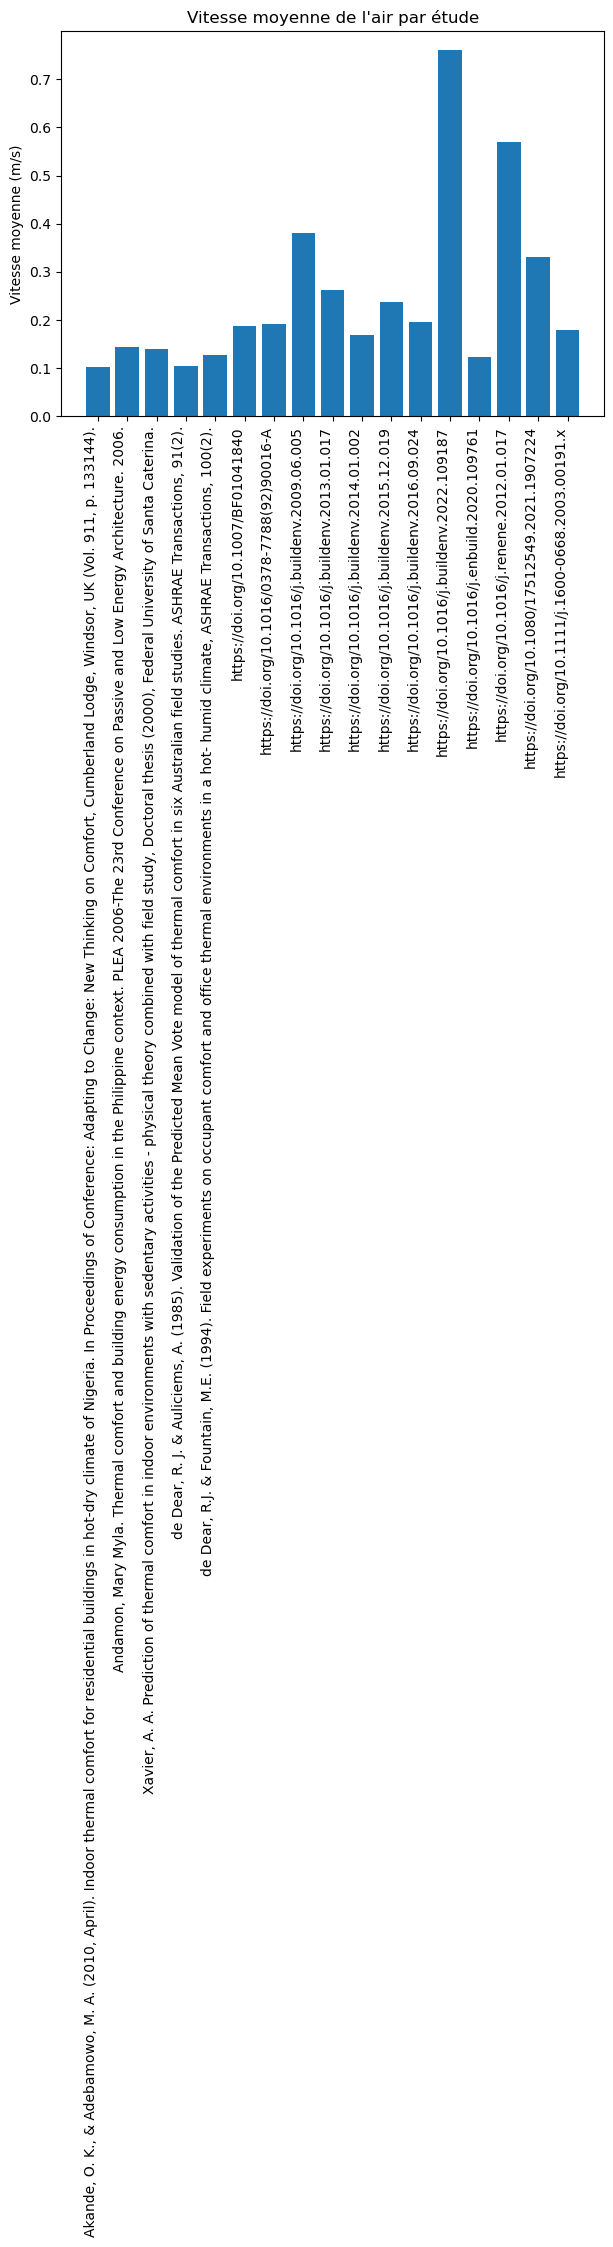

In [67]:
plt.figure(figsize=(7,5))

plt.bar(
    tableau["publication"],
    tableau["vel_moyenne"]
)

plt.xticks(rotation=90, ha="right")

plt.ylabel("Vitesse moyenne (m/s)")
plt.title("Vitesse moyenne de l'air par étude")

plt.tight_layout()
plt.savefig(os.path.join(GRAPH, "fig2_seuils_vitesse_air.png"), dpi=300)
plt.show()

In [56]:
print("=" * 70)
print("ETAPE 6 : diversité des personnes")
print("=" * 70)

ETAPE 6 : diversité des personnes


In [57]:
print("\nGenre :")
print(df_tropical_avec_vel["gender"].value_counts(dropna=False))

print("\nÂge")
print("Minimum :", df_tropical_avec_vel["age"].min())
print("Moyenne :", round(df_tropical_avec_vel["age"].mean(),1))
print("Maximum :", df_tropical_avec_vel["age"].max())

pct_age = df_tropical_avec_vel["age"].notna().mean()*100
print("Âge renseigné :", round(pct_age,1), "%")


Genre :
gender
female    8251
male      8017
NaN       1336
Name: count, dtype: int64

Âge
Minimum : 16.0
Moyenne : 31.2
Maximum : 83.0
Âge renseigné : 68.7 %


In [58]:
print("=" * 70)
print("ETAPE 7 : cartographie + Köppen + mes 6 études")
print("=" * 70)

ETAPE 7 : cartographie + Köppen + mes 6 études


groupe
Tempéré        347
Tropical       253
Aride          171
Continental     38
Name: count, dtype: int64


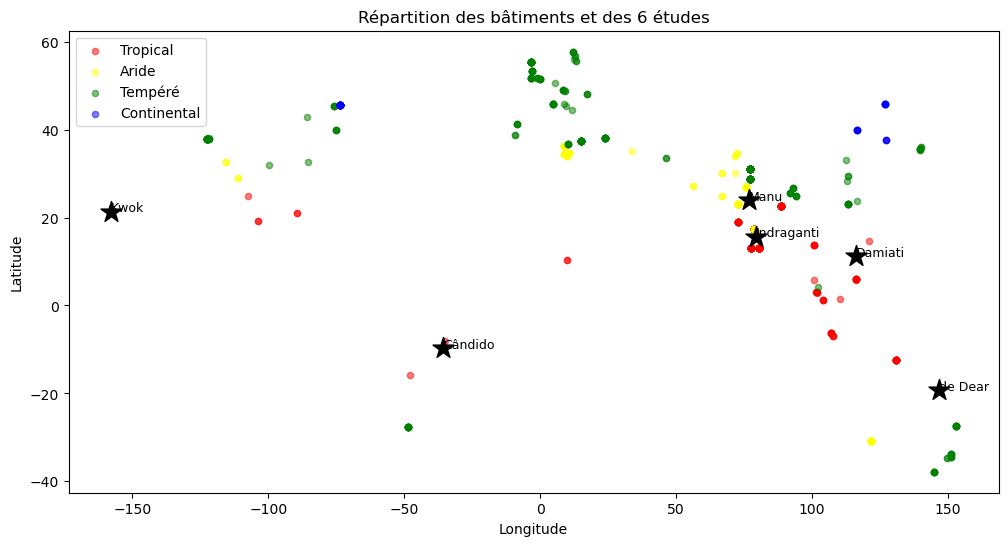

In [65]:
# Regroupement plus facile des climats

groupe_A = climats_tropicaux

groupe_B = [
    "hot semi-arid",
    "hot arid",
    "hot desert",
    "cold semi-arid",
    "desert (hot arid)",
    "semi arid midlatitude",
    "semi arid high altitude",
    "subtropical hot and dry"
]

groupe_D = [
    "continental subarctic",
    "monsoon-influenced hot-summer humid continental",
    "warm-summer humid continental"
]

meta["groupe"] = "Tempéré"

meta.loc[meta["climate"].isin(groupe_A), "groupe"] = "Tropical"
meta.loc[meta["climate"].isin(groupe_B), "groupe"] = "Aride"
meta.loc[meta["climate"].isin(groupe_D), "groupe"] = "Continental"

print(meta["groupe"].value_counts())

# Mes 6 études

etudes = {
    "Indraganti": indraganti,
    "Cândido": cândido,
    "Kwok": kwok,
    "Manu": manu,
    "Damiati": damiati,
    "de Dear": dear
}


couleurs = {
    "Tropical": "red",
    "Aride": "yellow",
    "Tempéré": "green",
    "Continental": "blue"
}

# Carte

plt.figure(figsize=(12,6))

for climat in couleurs:

    sous_base = meta[meta["groupe"] == climat]

    plt.scatter(
        sous_base["lon"],
        sous_base["lat"],
        color=couleurs[climat],
        s=20,
        alpha=0.5,
        label=climat
    )


for nom in etudes:

    etude = etudes[nom]

    plt.scatter(
        etude["lon"].mean(),
        etude["lat"].mean(),
        color="black",
        marker="*",
        s=250
    )

    plt.text(
        etude["lon"].mean(),
        etude["lat"].mean(),
        nom,
        fontsize=9
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Répartition des bâtiments et des 6 études")

plt.legend()

plt.savefig(os.path.join(GRAPH, "fig3_cartographie.png"), dpi=300)

plt.show()

In [60]:
import os
print(os.getcwd())

C:\Users\Icebear\Documents\PFE\Cassy\files


In [61]:
print(OUT)

resultats


In [62]:
import os

for f in os.listdir(OUT):
    print(f)

csv
graphiques
resume_par_etude.csv
